In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [8, 5]
plt.rcParams["figure.figsize"] = [8, 7]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50
plt.figure(dpi=1200)

<Figure size 9600x8400 with 0 Axes>

<Figure size 9600x8400 with 0 Axes>

In [3]:
op_pulse = []
out_init01 = []
out_init11 = []

# Add Segmented500_53S_5L_BrrX
root_dir = "Segmented500_53S_5L_BrrX"
data_dir_prefix = "Segmented500_53S_5L_Brr"
brr = [50]
for i in range(len(brr)):
    op_pulse.append(np.load("../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))
    
    # popevo01
    out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, brr[i])
    out_init01.append(np.load(out_init01_file, allow_pickle=True))

    # popevo11
    out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, brr[i])
    out_init11.append(np.load(out_init11_file, allow_pickle=True))
    
# Add Segmented500_DeltaX
root_dir = "Segmented500_DeltaX"
data_dir_prefix = "Segmented500_Delta"
delta_p = [2]
for i in range(len(delta_p)):
    op_pulse.append(np.load("../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, delta_p[i]), allow_pickle=True))
    
    # popevo01
    out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, delta_p[i])
    out_init01.append(np.load(out_init01_file, allow_pickle=True))

    # popevo11
    out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, delta_p[i])
    out_init11.append(np.load(out_init11_file, allow_pickle=True))

In [4]:
pulse_Omega1 = []
pulse_Omega2 = []
pulse_Delta1 = []

for i in range(len(brr+delta_p)):
    Omega1 = op_pulse[i]['Omega1']
    Omega2 = op_pulse[i]['Omega2']
    Delta1 = op_pulse[i]['Delta1']
    T_gate = op_pulse[i]['T_gate']
    
    Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
              'Delta1': Delta1, 
              'T_gate': T_gate}
    times = np.linspace(0.0, T_gate, 100)

    # Pulse shape
    T_gate = Pulses['T_gate'][0]         # (mu s) Total gate time
    n = 12   # Number of segments
    dt = T_gate/n       # (mu s) Duration of each segment

    def Pshape(t, pulse_coe):
        ith = int( (t - dt/2) // dt )
        ti = dt/2 + dt*ith
        ti1 = ti + dt
        if t < dt/2 or t > (T_gate - dt/2):
            fi = pulse_coe[0]
            fi1 = pulse_coe[0]
            ft = (fi + fi1)/2 
        else:
            if ith < 5:
                ith1 = ith + 1
                fi = pulse_coe[ith]
                fi1 = pulse_coe[ith1]
                ft = ( (fi + fi1)/2 + ( (fi1-fi)/2 ) * math.erf( (5/dt) * ( t - (ti + ti1)/2 ) ) )

            elif ith == 5:
                ith1 = ith
                fi = pulse_coe[ith]
                fi1 = pulse_coe[ith1]
                ft = ( (fi + fi1)/2 + ( (fi1-fi)/2 ) * math.erf( (5/dt) * ( t - (ti + ti1)/2 ) ) )

            elif ith > 5:
                ith1 = ith + 1
                fi = pulse_coe[n-ith-1]
                fi1 = pulse_coe[n-ith1-1]
                ft  = ( (fi + fi1)/2 + ( (fi1-fi)/2 ) * math.erf( (5/dt) * ( t - (ti + ti1)/2 ) ) )
        return ft
    
    pulse_Omega1_temp = []
    pulse_Omega2_temp = []
    pulse_Delta1_temp = []
    for t in times:
        pulse_Omega1_temp.append( Pshape(t, Omega1))
        pulse_Omega2_temp.append( Omega2[0] )
        pulse_Delta1_temp.append( Delta1[0] )

    pulse_Omega1.append(pulse_Omega1_temp)
    pulse_Omega2.append(pulse_Omega2_temp)
    pulse_Delta1.append(pulse_Delta1_temp)

/tmp/ipykernel_73096/926469456.py:92: MatplotlibDeprecationWarning: Passing the emit parameter of set_ylim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  axet.set_ylim(2.25, 0, -1)


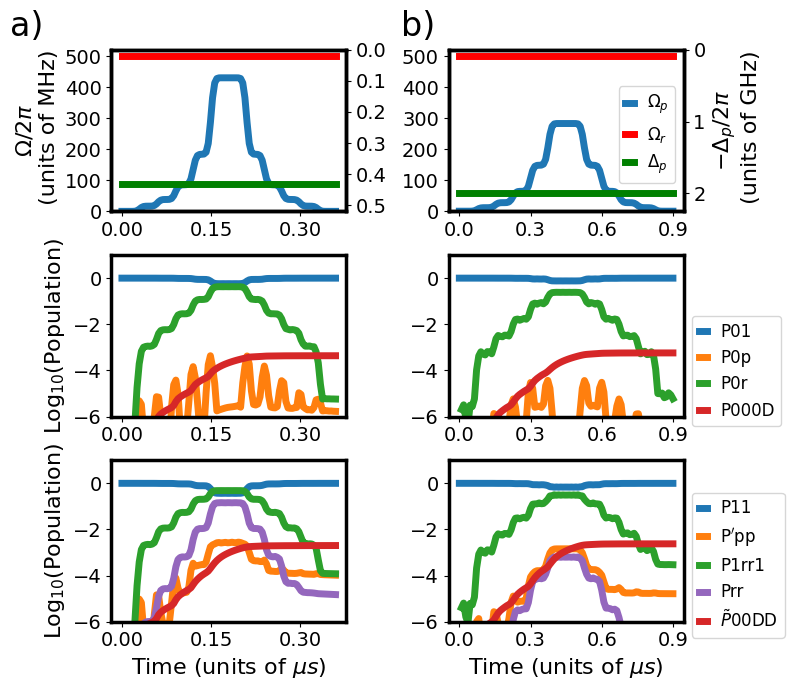

In [15]:
fig, axs = plt.subplots(3,2)

# axb = axs[0]
# axc = axs[1]
# axd = axs[2]

# axa = axs[0,0]
# axh = axs[0, 0]
# axi = axs[1, 0]
# axj = axs[2, 0]
axb = axs[0, 0]
axc = axs[1, 0]
axd = axs[2, 0]
axe = axs[0, 1]
axf = axs[1, 1]
axg = axs[2, 1]


# b)
times = np.linspace(0.0, op_pulse[0]['T_gate'],  100)
xinterval = np.arange(0, 0.42, 0.15)
#axb
axbp = axb.plot(times, pulse_Omega1[0], linewidth=5, label=r'$\Omega_p$')
axbp2 = axb.plot(times, pulse_Omega2[0], linewidth=5, label=r'$\Omega_r$', color='r')
axbt = axb.twinx()
axbtp = axbt.plot(times, [-x/1000 for x in pulse_Delta1[0]], linewidth=5, label=r'$\Delta_p$', color='g')
axbld = axbp + axbp2 + axbtp
axblb = [lb.get_label() for lb in axbld]

axb.set_ylim(0, 520)
axbt.set_ylim(0.52, 0)
axb.set_ylabel(r'$\Omega / 2 \pi$' '\n' ' (units of MHz)', fontsize=16)
axb.set_xticks(xinterval)
yinterval = np.arange(0, 520, 100)
y1interval = np.arange(0.5, -0.02, -0.1)
axb.set_yticks(yinterval)
axbt.set_yticks(y1interval)
axb.tick_params(axis='x', labelsize=14)
axb.tick_params(axis='y', labelsize=14)
axbt.tick_params(axis='y', rotation=0, labelsize=14)
axb.set_title('a)', x=-0.36, pad=10, fontsize=24)


#axc
axc.plot(times, out_init01[0]["P01"], linewidth=5) 
axc.plot(times, out_init01[0]["P0p"], linewidth=5)
axc.plot(times, out_init01[0]["P0r"], linewidth=5)
axc.plot(times, out_init01[0]["P000d"], linewidth=5)
axc.set_ylim(-6, 1)
yinterval = np.arange(0, -6.2, -2)
axc.set_yticks(yinterval)
axc.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# axc.legend(("P01", "P0p", "P0r", "P000D"), fontsize=10)
axc.set_xticks(xinterval)
axc.tick_params(axis='x', labelsize=14)
axc.tick_params(axis='y', labelsize=14)
# axc.set_title('b)', loc='left', pad=10)

#axd
axd.plot(times, out_init11[0]["P11"], linewidth=5) 
axd.plot(times, out_init11[0]["Ppp"], linewidth=5)
axd.plot(times, out_init11[0]["P1rr1"], linewidth=5)
axd.plot(times, out_init11[0]["Prr"], linewidth=5, color='tab:purple')
axd.plot(times, out_init11[0]["P00dd"], linewidth=5, color='tab:red')
axd.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
axd.set_ylim(-6, 1)
yinterval = np.arange(0, -6.2, -2)
axd.set_yticks(yinterval)
axd.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# axd.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), fontsize=10)
axd.set_xticks(xinterval)
axd.tick_params(axis='x', labelsize=14)
axd.tick_params(axis='y', labelsize=14)
# axd.set_title('c)', loc='left', pad=10)


# c)
times = np.linspace(0.0, op_pulse[1]['T_gate'],  100)
xinterval = np.arange(0, 1.2, 0.3)
#axe
axep = axe.plot(times, pulse_Omega1[1], linewidth=5, label=r'$\Omega_p$')
axep2 = axe.plot(times, pulse_Omega2[1], linewidth=5, label=r'$\Omega_r$', color='r')
axet = axe.twinx()
axetp = axet.plot(times, [-x/1000 for x in pulse_Delta1[1]], linewidth=5, label=r'$\Delta_p$', color='g')
axeld = axep + axep2 + axetp
axelb = [lb.get_label() for lb in axeld]
axe.legend(axeld, axelb, bbox_to_anchor=(1., .825), fontsize=12, handlelength=0.5)

axet.set_ylabel(r'$-\Delta_p / 2 \pi$' '\n' ' (units of GHz)', fontsize=16)

axe.set_ylim(0, 520)
axet.set_ylim(2.25, 0, -1)
axe.set_xticks(xinterval)
yinterval = np.arange(0, 520, 100)
axe.set_yticks(yinterval)
axe.tick_params(axis='x', labelsize=14)
axe.tick_params(axis='y', labelsize=14)
axet.tick_params(axis='y', rotation=0, labelsize=14)
axe.set_title('b)', x=-0.13, pad=10, fontsize=24)

#axf
axf.plot(times, out_init01[1]["P01"], linewidth=5) 
axf.plot(times, out_init01[1]["P0p"], linewidth=5)
axf.plot(times, out_init01[1]["P0r"], linewidth=5)
axf.plot(times, out_init01[1]["P000d"], linewidth=5)
# axf.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12)
axf.set_ylim(-6, 1)
yinterval = np.arange(0, -6.2, -2)
axf.set_yticks(yinterval)
# axf.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=12) 
axf.legend(("P01", "P0p", "P0r", "P000D"), bbox_to_anchor=(1., .675), fontsize=12, handlelength=0.5)
axf.set_xticks(xinterval)
axf.tick_params(axis='x', labelsize=14)
axf.tick_params(axis='y', labelsize=14)
# axf.set_title('e)', loc='left', pad=10)

#axg
axg.plot(times, out_init11[1]["P11"], linewidth=5) 
axg.plot(times, out_init11[1]["Ppp"], linewidth=5)
axg.plot(times, out_init11[1]["P1rr1"], linewidth=5)
axg.plot(times, out_init11[1]["Prr"], linewidth=5, color='tab:purple')
axg.plot(times, out_init11[1]["P00dd"], linewidth=5, color='tab:red')
axg.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
axg.set_ylim(-6, 1)
yinterval = np.arange(0, -6.2, -2)
axg.set_yticks(yinterval)
# axg.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=12) 
axg.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), bbox_to_anchor=(1., .85), fontsize=12, handlelength=0.5)
axg.set_xticks(xinterval)
axg.tick_params(axis='x', labelsize=14)
axg.tick_params(axis='y', labelsize=14)

plt.savefig('fig4.eps', dpi=1200)